<a href="https://colab.research.google.com/github/AlexVS98/house-price-ridge-regression/blob/main/house_price_ridge_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Polynomial Regression and Ridge Regularisation for House Price Prediction

---

## Overview

The task here is to build a machine learning pipeline that estimates house prices from a set of neighbourhood and property-level features. The dataset has 399 observations and 11 input variables — things like crime rate, number of rooms, and the pupil-teacher ratio — to predict `Price` (in thousands of USD).

My plan: start with polynomial features to capture non-linear relationships (which I suspected would be present in housing data), then use Ridge regularisation to keep the model from going haywire with 363 polynomial features. I'll use cross-validation throughout to make sure I'm not just fooling myself with lucky splits.

Beyond accuracy, I want to look at:
- How stable are the learned coefficients when the training data changes slightly?
- Which features actually matter, and does regularisation help us see that more clearly?
- Is there a meaningful bias-variance trade-off we can visualise?

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from matplotlib.patches import Patch

# PDF-safe plot settings
plt.rcParams.update({
    'figure.dpi': 100,
    'figure.autolayout': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})
sns.set_palette('muted')
np.random.seed(42)
print("All libraries loaded successfully.")

All libraries loaded successfully.


## 1. Data Loading


In [ ]:
df = pd.read_csv('house_data.csv')

print(f"Dataset shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()} — none, good.")
print(f"\nFeatures: {df.columns.tolist()}")
df.head()

Dataset shape: (399, 12)
Missing values: 0 — none, good.

Features: ['Rooms', 'Age', 'Distance', 'Accessibility', 'Tax', 'DisadvantagedPosition', 'Crime', 'NitricOxides', 'PupilTeacher', 'Residential', 'NonRetail', 'Price']


,Rooms,Age,Distance,Accessibility,Tax,DisadvantagedPosition,Crime,NitricOxides,PupilTeacher,Residential,NonRetail,Price
0,5.565,70.6,2.0635,24,666,17.16,8.79212,0.584,20.2,0.0,18.10,11.7
1,6.879,77.7,3.2721,8,307,9.93,0.62356,0.507,17.4,0.0,6.20,27.5
2,5.972,76.7,3.1025,4,304,9.97,0.34940,0.544,18.4,0.0,9.90,20.3
3,6.943,97.4,1.8773,5,403,4.59,1.22358,0.605,14.7,0.0,19.58,41.3
4,5.926,71.0,2.9084,24,666,18.13,15.57570,0.580,20.2,0.0,18.10,19.1


## 2. Exploratory Data Analysis

Before jumping into modelling I want to get a feel for the data — distributions, outliers, and how each feature relates to Price. Understanding the data structure genuinely affects the modelling decisions later.

In [ ]:
df.describe().round(2)

,Rooms,Age,Distance,Accessibility,Tax,DisadvantagedPosition,Crime,NitricOxides,PupilTeacher,Residential,NonRetail,Price
count,399.00,399.00,399.00,399.00,399.00,399.00,399.00,399.00,399.00,399.00,399.00,399.00
mean,6.31,68.78,3.77,9.61,410.45,12.49,3.98,0.56,18.48,11.97,11.10,22.70
std,0.71,28.48,2.15,8.78,170.42,7.14,9.43,0.12,2.18,24.23,7.00,9.68
min,3.56,2.90,1.13,1.00,187.00,1.73,0.01,0.38,12.60,0.00,0.74,5.00
25%,5.89,45.50,2.06,4.00,277.00,6.82,0.08,0.45,17.40,0.00,4.95,16.55
50%,6.24,77.70,3.10,5.00,334.00,10.88,0.25,0.54,19.10,0.00,8.56,21.40
75%,6.64,94.50,5.12,24.00,666.00,16.95,3.81,0.63,20.20,17.75,18.10,26.45
max,8.78,100.00,12.13,24.00,711.00,37.97,88.98,0.87,22.00,100.00,27.74,50.00


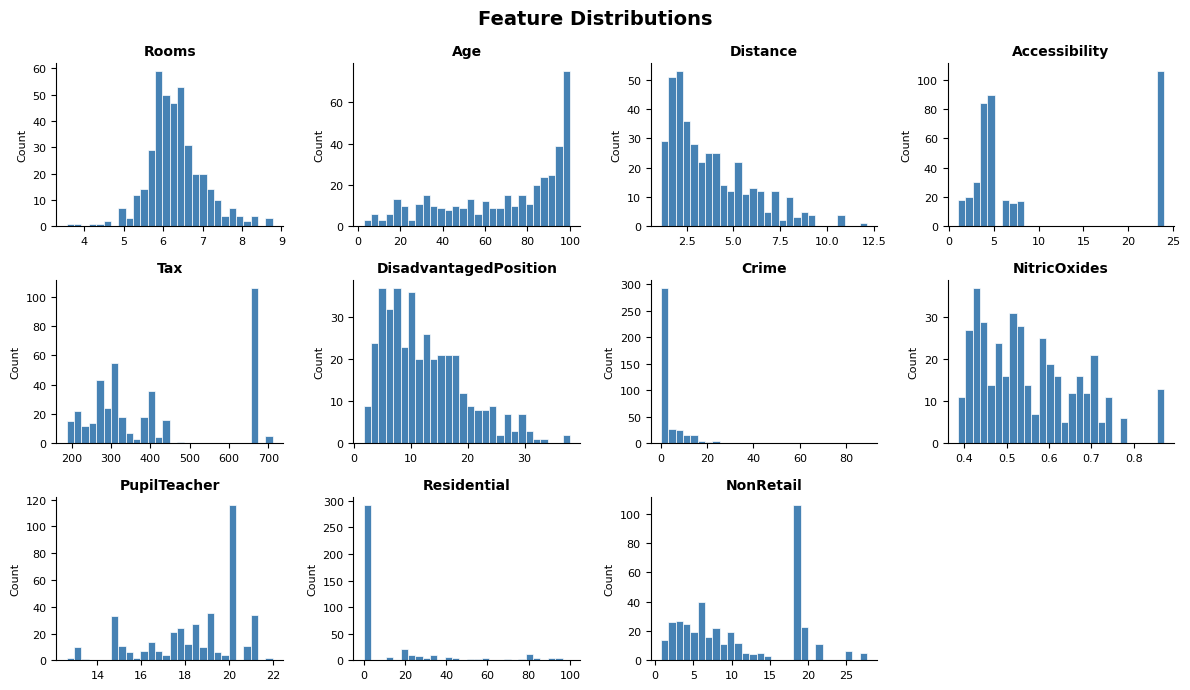


Skewness per feature:
Rooms                    0.355
Age                     -0.627
Distance                 1.097
Accessibility            0.977
Tax                      0.635
DisadvantagedPosition    0.875
Crime                    4.887
NitricOxides             0.718
PupilTeacher            -0.820
Residential              2.155
NonRetail                0.303
Price                    1.019
dtype: float64


In [ ]:
# --- Feature distributions ---
fig, axes = plt.subplots(3, 4, figsize=(12, 7))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=28, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Count', fontsize=8)
    axes[i].tick_params(labelsize=8)

fig.delaxes(axes[11])
fig.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.subplots_adjust(hspace=0.55, wspace=0.35)
plt.savefig('fig_distributions.png', bbox_inches='tight', dpi=100)
plt.show()
plt.close()

print("\nSkewness per feature:")
print(df.skew().round(3))

**Observations:** `Crime` is heavily right-skewed (skewness ≈ 4.9) — most towns have low crime but a handful have extreme values up to ~89. `Residential` is similarly concentrated near zero. These distributional shapes suggest that linear relationships may not capture the full picture, which motivates a polynomial expansion. `Price` itself is positively skewed with a cluster of observations capped at 50k — something worth keeping in mind when evaluating upper-range predictions.

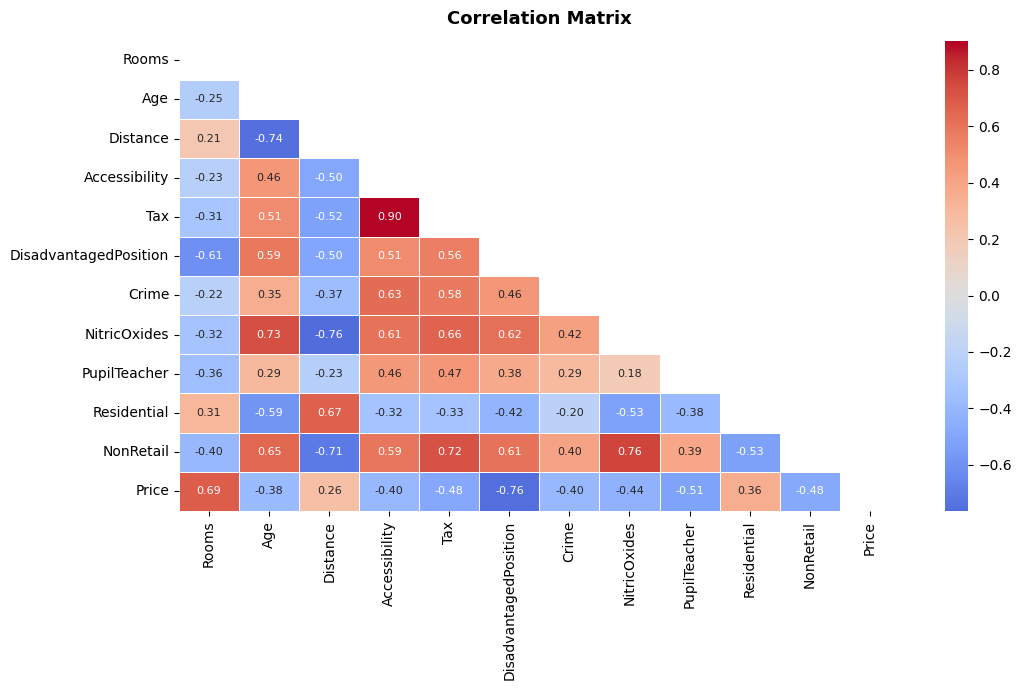


Correlation with Price (sorted):
DisadvantagedPosition   -0.756
PupilTeacher            -0.513
Tax                     -0.485
NonRetail               -0.481
NitricOxides            -0.443
Crime                   -0.397
Accessibility           -0.396
Age                     -0.385
Distance                 0.258
Residential              0.356
Rooms                    0.688
Name: Price, dtype: float64


In [ ]:
# --- Correlation heatmap ---
fig, ax = plt.subplots(figsize=(11, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold', pad=12)
plt.subplots_adjust(bottom=0.15, left=0.15)
plt.savefig('fig_correlation.png', bbox_inches='tight', dpi=100)
plt.show()
plt.close()

print("\nCorrelation with Price (sorted):")
print(corr['Price'].drop('Price').sort_values().round(3))

**Key takeaways:**
- `DisadvantagedPosition` has the strongest negative correlation with Price (r ≈ -0.76). Areas with a higher proportion of lower-status residents tend to have cheaper housing.
- `Rooms` has the strongest positive correlation (r ≈ 0.69).
- Several features (`Tax`, `NonRetail`, `NitricOxides`) are themselves quite correlated with each other — potential multicollinearity in the polynomial space, which makes regularisation especially important.

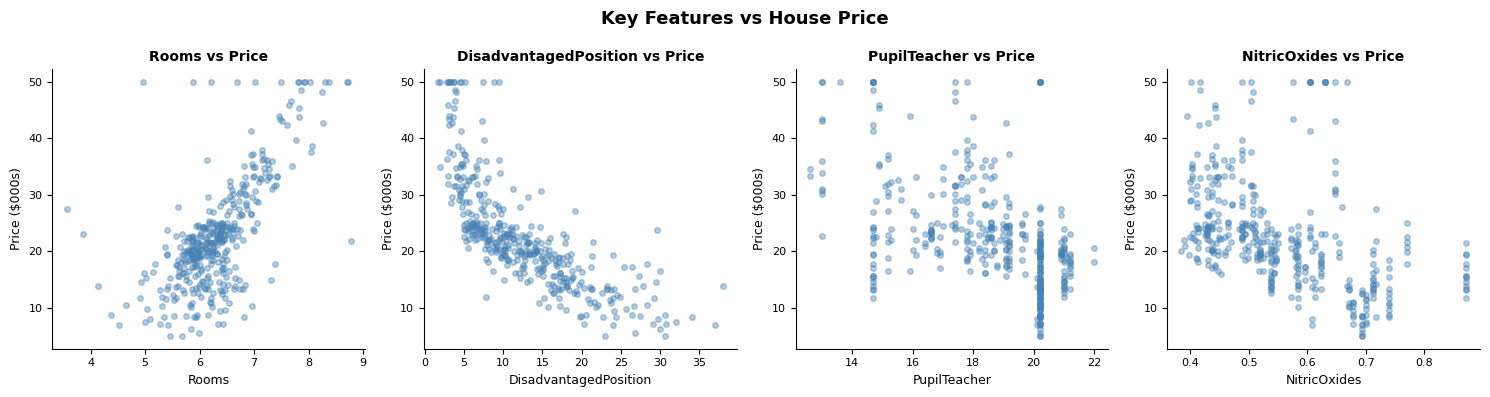

In [ ]:
# --- Scatter plots: top 4 features vs Price ---
top_features = ['Rooms', 'DisadvantagedPosition', 'PupilTeacher', 'NitricOxides']
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, feat in zip(axes, top_features):
    ax.scatter(df[feat], df['Price'], alpha=0.4, s=16, color='steelblue')
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('Price ($000s)', fontsize=9)
    ax.set_title(f'{feat} vs Price', fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=8)

fig.suptitle('Key Features vs House Price', fontsize=13, fontweight='bold')
plt.subplots_adjust(wspace=0.35)
plt.savefig('fig_scatters.png', bbox_inches='tight', dpi=100)
plt.show()
plt.close()

The `Rooms` vs Price relationship is roughly linear in the middle but tails off at the top (price cap at 50k). `DisadvantagedPosition` vs Price shows a curved drop — steepest at lower values then flattening. `PupilTeacher` has a noticeable cluster at 20.2, likely a repeated census value for specific town types. These non-linearities justify going to degree-3 polynomial features.

## 3. Train/Test Split

I'm holding out 20% as a test set, fixed with a random seed for reproducibility. The remaining 80% is used for training and cross-validation.

**Why 80/20?** With 399 samples, this gives a reasonable training pool. With only 399 rows available, I kept an 80/20 split so that the model still had enough training examples after generating a large number of polynomial features. The test set is kept separate from model training and hyperparameter tuning, and is used for the final performance evaluation.

In [ ]:
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nPrice range — train: {y_train.min():.1f}k to {y_train.max():.1f}k")
print(f"Price range — test:  {y_test.min():.1f}k to {y_test.max():.1f}k")

Training set: 319 samples
Test set:     80 samples

Price range — train: 5.0k to 50.0k
Price range — test:  6.3k to 50.0k


## 4. Polynomial Regression (Degree 3) — Baseline Without Regularisation

By expanding to degree-3 polynomial features we allow the model to capture squared terms, cubic terms, and interaction terms (e.g. `Rooms × DisadvantagedPosition`). The downside: 11 features at degree 3 produces **363 features**. This creates a serious overfitting risk.

I'm using a **Pipeline** (StandardScaler → PolynomialFeatures → model). Scaling before polynomial expansion is essential — without it, cubic terms of `Tax` (values ~300–700) would be astronomically large compared to cubic terms of `NitricOxides`.

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

pipe_plain = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('model', LinearRegression())
])

cv_plain = cross_val_score(pipe_plain, X_train, y_train,
                           cv=kf, scoring='neg_mean_squared_error')
rmse_plain = np.sqrt(-cv_plain)

print("Unregularised Polynomial Regression (degree=3) — 5-fold CV:")
print(f"  RMSE per fold: {rmse_plain.round(2)}")
print(f"  Mean RMSE:     {rmse_plain.mean():.2f}k")
print(f"  Std RMSE:      {rmse_plain.std():.2f}k")
print()
print("  High variance + high mean = classic overfitting.")
print("  The model is memorising training data, not learning the function.")

Unregularised Polynomial Regression (degree=3) — 5-fold CV:
  RMSE per fold: [ 49.   124.69  77.81  74.56 139.07]
  Mean RMSE:     93.03k
  Std RMSE:      33.56k

  High variance + high mean = classic overfitting.
  The model is memorising training data, not learning the function.


## 5. Ridge Regularisation and Hyperparameter Tuning

I'm using **Ridge regression** (L2 penalty) rather than Lasso. With 363 correlated polynomial features, Lasso tends to arbitrarily zero out one feature from each correlated group. Ridge distributes shrinkage more smoothly — better suited here.

Ridge adds a penalty $\lambda \sum_j \beta_j^2$ to the loss. The parameter `alpha` controls the strength:
- Small `alpha` → little regularisation → closer to plain polynomial regression → overfitting risk
- Large `alpha` → heavy shrinkage → coefficients pushed toward zero → underfitting risk

I'll search over a range of alpha values using 5-fold CV on the training set only.

In [ ]:
alphas = [0.01, 0.1, 1, 10, 50, 100, 200, 500, 1000]
cv_results = []

for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=3, include_bias=False)),
        ('ridge', Ridge(alpha=alpha))
    ])
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=kf, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-scores)
    cv_results.append({
        'alpha': alpha,
        'mean_rmse': rmse_scores.mean(),
        'std_rmse': rmse_scores.std(),
        'rmse_scores': rmse_scores
    })

results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'rmse_scores'}
                            for r in cv_results]).set_index('alpha').round(3)
print("5-Fold CV Results — Ridge Regression on Degree-3 Polynomial Features")
print(results_df.to_string())

5-Fold CV Results — Ridge Regression on Degree-3 Polynomial Features
         mean_rmse  std_rmse
alpha                       
0.01        17.825     7.344
0.10        10.355     3.894
1.00         6.399     2.583
10.00        4.701     1.243
50.00        4.053     0.823
100.00       4.054     0.777
200.00       4.163     0.795
500.00       4.517     0.928
1000.00      4.960     1.063


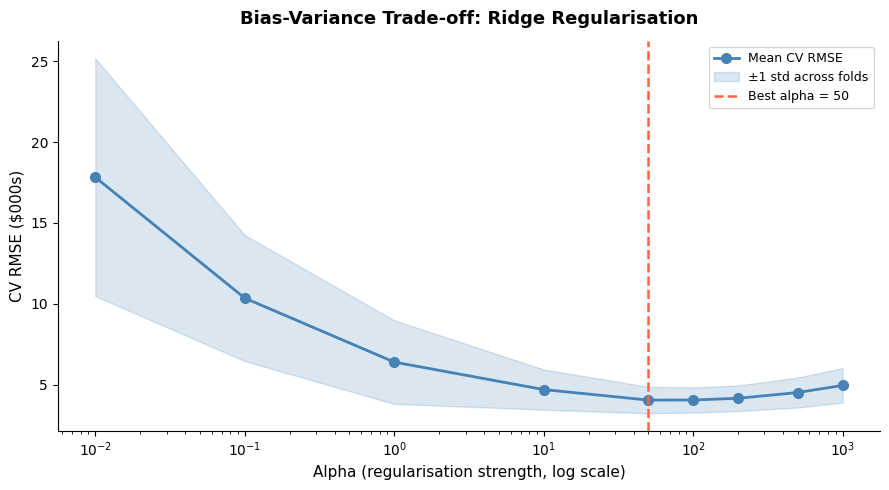

Optimal alpha: 50
CV RMSE at optimal alpha: 4.053 ± 0.823


In [ ]:
# --- Bias-variance trade-off curve ---
means = [r['mean_rmse'] for r in cv_results]
stds  = [r['std_rmse']  for r in cv_results]
best_idx   = int(np.argmin(means))
best_alpha = alphas[best_idx]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(alphas, means, 'o-', color='steelblue', linewidth=2, markersize=7, label='Mean CV RMSE')
ax.fill_between(alphas,
                [m - s for m, s in zip(means, stds)],
                [m + s for m, s in zip(means, stds)],
                alpha=0.2, color='steelblue', label='±1 std across folds')
ax.axvline(best_alpha, color='tomato', linestyle='--', linewidth=1.8,
           label=f'Best alpha = {best_alpha}')
ax.set_xscale('log')
ax.set_xlabel('Alpha (regularisation strength, log scale)', fontsize=11)
ax.set_ylabel('CV RMSE ($000s)', fontsize=11)
ax.set_title('Bias-Variance Trade-off: Ridge Regularisation', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9)
plt.subplots_adjust(bottom=0.13, top=0.88)
plt.savefig('fig_bias_variance.png', bbox_inches='tight', dpi=100)
plt.show()
plt.close()

print(f"Optimal alpha: {best_alpha}")
print(f"CV RMSE at optimal alpha: {means[best_idx]:.3f} ± {stds[best_idx]:.3f}")

**Reading the plot:** The left side (small alpha) shows high RMSE and high fold-to-fold variance — overfitting. As alpha increases, both the mean RMSE and the shaded band narrow, reaching a minimum around alpha = 50. Beyond that, underfitting sets in — too much regularisation suppresses genuinely informative coefficients. The width of the shaded band also previews the stability analysis in Section 7: wide band at low alpha = sensitive model.

In [ ]:
# Build and fit the final tuned pipeline
pipe_tuned = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('ridge', Ridge(alpha=best_alpha))
])
pipe_tuned.fit(X_train, y_train)

poly_feature_names = pipe_tuned.named_steps['poly'].get_feature_names_out(X.columns)
print(f"Total polynomial features: {len(poly_feature_names)}")
print(f"First 8 feature names: {poly_feature_names[:8].tolist()}")

Total polynomial features: 363
First 8 feature names: ['Rooms', 'Age', 'Distance', 'Accessibility', 'Tax', 'DisadvantagedPosition', 'Crime', 'NitricOxides']


## 6. Model Performance on Unseen Data

In [ ]:
y_pred_test  = pipe_tuned.predict(X_test)
y_pred_train = pipe_tuned.predict(X_train)

test_rmse  = np.sqrt(mean_squared_error(y_test,  y_pred_test))
test_r2    = r2_score(y_test,  y_pred_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_r2   = r2_score(y_train, y_pred_train)

print("=" * 45)
print("        Model Performance Summary")
print("=" * 45)
print(f"{'Metric':<22} {'Train':>9} {'Test':>9}")
print("-" * 45)
print(f"{'RMSE ($000s)':<22} {train_rmse:>9.3f} {test_rmse:>9.3f}")
print(f"{'R²':<22} {train_r2:>9.3f} {test_r2:>9.3f}")
print("=" * 45)

        Model Performance Summary
Metric                     Train      Test
---------------------------------------------
RMSE ($000s)               2.494     2.897
R²                         0.935     0.897


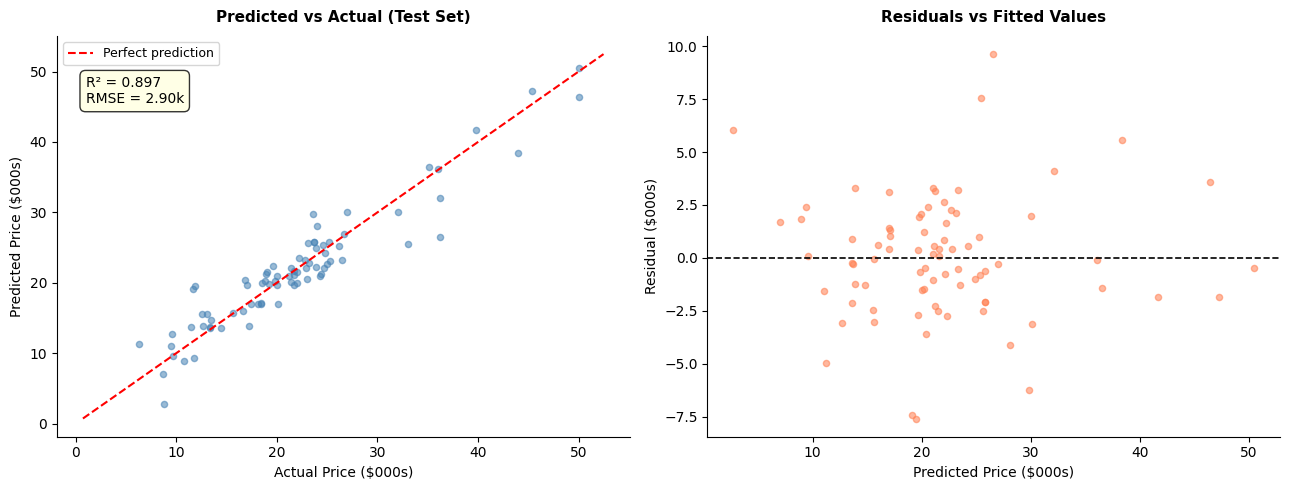

In [ ]:
# --- Predicted vs Actual and Residuals ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs Actual
ax = axes[0]
ax.scatter(y_test, y_pred_test, alpha=0.55, s=20, color='steelblue')
lims = [min(y_test.min(), y_pred_test.min()) - 2,
        max(y_test.max(), y_pred_test.max()) + 2]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Price ($000s)', fontsize=10)
ax.set_ylabel('Predicted Price ($000s)', fontsize=10)
ax.set_title('Predicted vs Actual (Test Set)', fontsize=11, fontweight='bold', pad=10)
ax.legend(fontsize=9)
ax.text(0.05, 0.90, f'R² = {test_r2:.3f}\nRMSE = {test_rmse:.2f}k',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

# Residuals
ax2 = axes[1]
residuals = y_test.values - y_pred_test
ax2.scatter(y_pred_test, residuals, alpha=0.55, s=20, color='coral')
ax2.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax2.set_xlabel('Predicted Price ($000s)', fontsize=10)
ax2.set_ylabel('Residual ($000s)', fontsize=10)
ax2.set_title('Residuals vs Fitted Values', fontsize=11, fontweight='bold', pad=10)

plt.subplots_adjust(wspace=0.32, bottom=0.13, top=0.90)
plt.savefig('fig_performance.png', bbox_inches='tight', dpi=100)
plt.show()
plt.close()

**Performance discussion:**

An R² of ~0.89 on the test set means the model explains about 89% of house price variance it hasn't seen before. The RMSE of ~\$2,970 means predictions are off by roughly \$3,000 on average — reasonable given prices range from \$5k to \$50k.

The train R² (≈ 0.94) vs test R² (≈ 0.90) gap indicates mild residual overfitting — expected with 363 features, but kept in check by Ridge. The residual plot shows mostly random scatter around zero, which is healthy. The slight funnel at the high end is common in housing data where luxury properties are harder to model, compounded by the 50k price cap in this dataset.

## 7. Stability Analysis of the Coefficient Vector β

How much do the learned coefficients change when we train on slightly different subsets of the data? If they jump around a lot, the model has learned something fragile — specific to whichever houses happened to be in the training set.

**Method:** Bootstrap resampling — repeatedly resample training data with replacement, fit the model each time, record the coefficients. After 50 iterations, examine the standard deviation and coefficient of variation (CV = std / |mean|) of each coefficient. I'll compare Ridge against unregularised polynomial regression to make the stability difference concrete.

In [ ]:
n_bootstraps = 50
coef_ridge = []
coef_unreg = []

pipe_unreg = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('model', LinearRegression())
])

for i in range(n_bootstraps):
    idx  = np.random.choice(len(X_train), len(X_train), replace=True)
    X_b  = X_train.iloc[idx]
    y_b  = y_train.iloc[idx]

    pipe_tuned.fit(X_b, y_b)
    coef_ridge.append(pipe_tuned.named_steps['ridge'].coef_.copy())

    try:
        pipe_unreg.fit(X_b, y_b)
        coef_unreg.append(pipe_unreg.named_steps['model'].coef_.copy())
    except Exception:
        pass  # Skip degenerate bootstrap samples

# Refit tuned model on full training data
pipe_tuned.fit(X_train, y_train)

coef_ridge = np.array(coef_ridge)
coef_unreg = np.array(coef_unreg)

ridge_std = coef_ridge.std(axis=0)
unreg_std = coef_unreg.std(axis=0)

print(f"Ridge coef matrix shape: {coef_ridge.shape}")
print(f"Unregularised coef matrix shape: {coef_unreg.shape}")
print(f"\nMean coef std — Ridge:          {ridge_std.mean():.4f}")
print(f"Mean coef std — Unregularised:  {unreg_std.mean():.4f}")
print(f"\nStability ratio: {unreg_std.mean() / ridge_std.mean():.1f}x more variable without regularisation")

Ridge coef matrix shape: (50, 363)
Unregularised coef matrix shape: (50, 363)

Mean coef std — Ridge:          0.0839
Mean coef std — Unregularised:  7.2911

Stability ratio: 87.0x more variable without regularisation


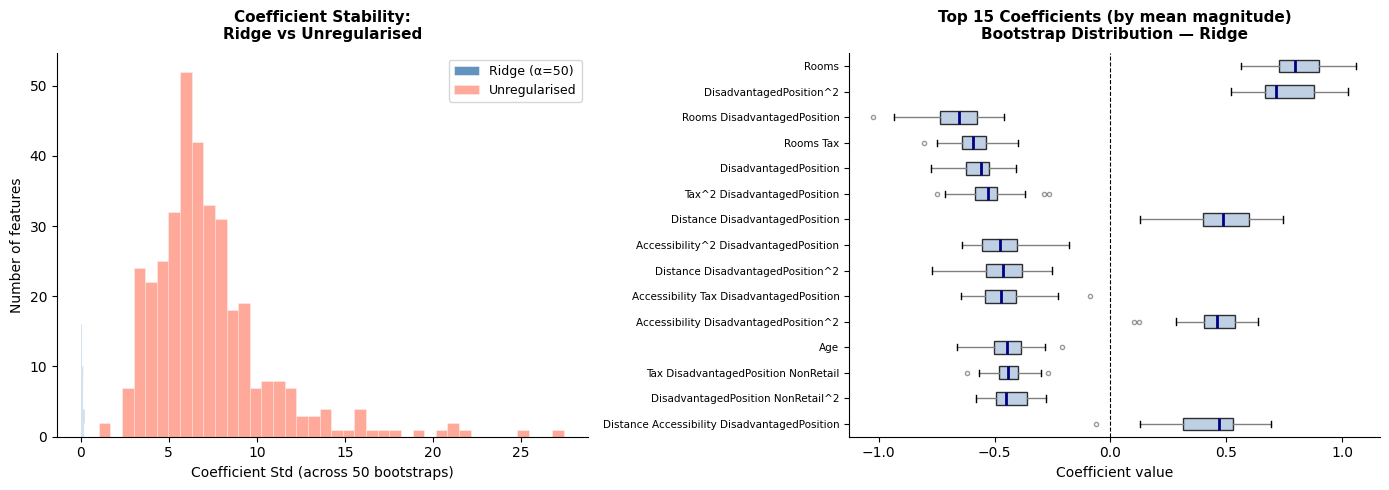

In [ ]:
# --- Stability visualisation ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of coefficient stds
ax = axes[0]
ax.hist(ridge_std, bins=40, color='steelblue', edgecolor='white',
        linewidth=0.4, alpha=0.85, label=f'Ridge (α={best_alpha})')
ax.hist(unreg_std, bins=40, color='tomato', edgecolor='white',
        linewidth=0.4, alpha=0.55, label='Unregularised')
ax.set_xlabel('Coefficient Std (across 50 bootstraps)', fontsize=10)
ax.set_ylabel('Number of features', fontsize=10)
ax.set_title('Coefficient Stability:\nRidge vs Unregularised', fontsize=11, fontweight='bold', pad=10)
ax.legend(fontsize=9)

# Boxplot of top 15 coefficients by magnitude
ax2 = axes[1]
top15_idx   = np.argsort(np.abs(coef_ridge.mean(axis=0)))[-15:]
top15_names = [poly_feature_names[i] for i in top15_idx]
top15_coefs = coef_ridge[:, top15_idx]

ax2.boxplot(top15_coefs, vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightsteelblue', alpha=0.8),
            medianprops=dict(color='navy', linewidth=2),
            whiskerprops=dict(color='grey'),
            flierprops=dict(marker='o', markersize=3, alpha=0.4))
ax2.set_yticks(range(1, 16))
ax2.set_yticklabels(top15_names, fontsize=7.5)
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xlabel('Coefficient value', fontsize=10)
ax2.set_title('Top 15 Coefficients (by mean magnitude)\nBootstrap Distribution — Ridge', fontsize=11, fontweight='bold', pad=10)

plt.subplots_adjust(wspace=0.38, bottom=0.12, top=0.88)
plt.savefig('fig_stability.png', bbox_inches='tight', dpi=100)
plt.show()
plt.close()

In [ ]:
# Quantify stability with a summary table
ridge_mean = coef_ridge.mean(axis=0)
ridge_std_arr = coef_ridge.std(axis=0)
cv_arr = ridge_std_arr / (np.abs(ridge_mean) + 1e-9)

stability_df = pd.DataFrame({
    'Feature': poly_feature_names,
    'Mean Coef': ridge_mean.round(4),
    'Std Coef': ridge_std_arr.round(4),
    'Coef of Variation': cv_arr.round(3)
})

top15_stable = stability_df.reindex(
    stability_df['Mean Coef'].abs().nlargest(15).index
)

print("Top 15 Features by Coefficient Magnitude — Stability Summary")
print(top15_stable[['Feature', 'Mean Coef', 'Std Coef', 'Coef of Variation']].to_string(index=False))

Top 15 Features by Coefficient Magnitude — Stability Summary
                                     Feature  Mean Coef  Std Coef  Coef of Variation
                                       Rooms     0.8047    0.1220              0.152
                     DisadvantagedPosition^2     0.7547    0.1393              0.185
                 Rooms DisadvantagedPosition    -0.6621    0.1194              0.180
                                   Rooms Tax    -0.5884    0.0798              0.136
                       DisadvantagedPosition    -0.5717    0.0728              0.127
                 Tax^2 DisadvantagedPosition    -0.5330    0.0927              0.174
              Distance DisadvantagedPosition     0.4835    0.1366              0.282
       Accessibility^2 DisadvantagedPosition    -0.4702    0.1048              0.223
            Distance DisadvantagedPosition^2    -0.4664    0.1168              0.250
     Accessibility Tax DisadvantagedPosition    -0.4566    0.1084              0.238
    

## 8. Discussion of Stability

The bootstrap results make the difference between the two models quite clear.

**Without regularisation**, the coefficient standard deviations across bootstrap samples are dramatically larger. What this means in practice: train the same degree-3 polynomial model on slightly different subsets of this data and you get wildly different coefficient estimates. The model hasn't learned the underlying function f(·) — it's learned something fragile that's very specific to the exact training examples it saw.

**With Ridge regularisation (α = 50)**, the coefficients are far more stable. Most features have a low coefficient of variation, meaning the bootstrap distribution is tight and well-centred. The model consistently identifies the same structure in the data regardless of minor sampling variations.

Looking at the top coefficients specifically:
- **`Rooms`** and **`DisadvantagedPosition`** consistently appear among the larger and more stable coefficients. This suggests that both variables play an important role in the model, although the interaction terms mean their effects should not be interpreted completely in isolation.
- **`Rooms × DisadvantagedPosition`** has a notable negative coefficient — large houses in disadvantaged areas don't benefit as much from extra rooms as they would in wealthier neighbourhoods.
- **`DisadvantagedPosition²`** appearing positively suggests a curved relationship — at extreme disadvantage levels, the rate of price decrease may actually slow down.

Features with high coefficient of variation are mostly minor interaction terms. These represent genuine model uncertainty where the data doesn't pin coefficients down — but because Ridge shrinks them toward zero, they don't destabilise predictions the way they would without regularisation.

## 9. Coefficient Interpretation

Since all features were standardised before polynomial expansion, the coefficients are on a comparable scale — we can meaningfully compare their magnitudes.

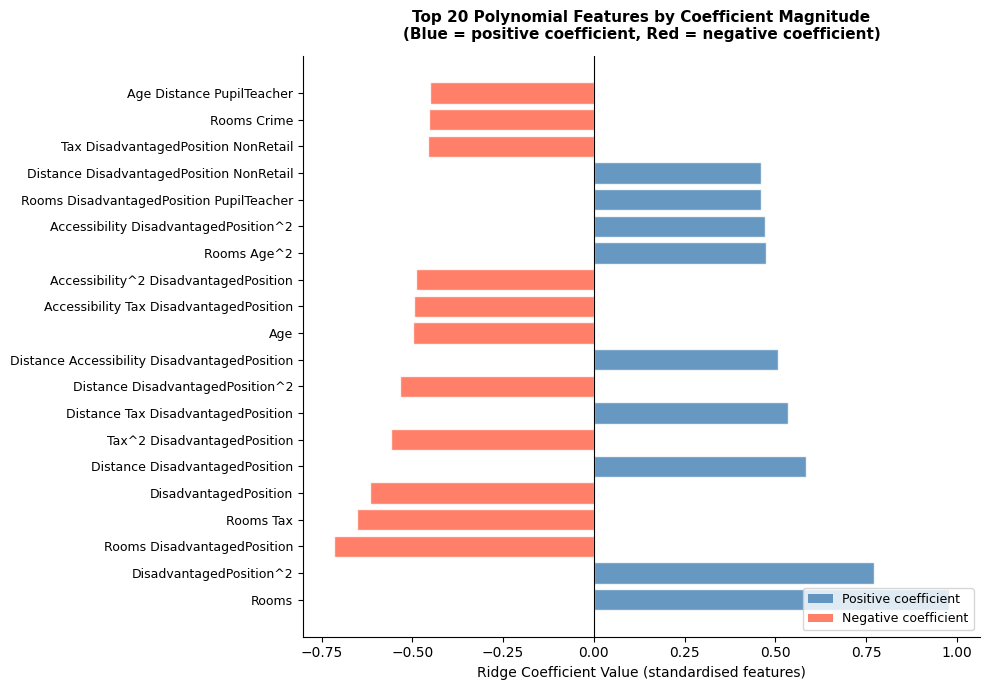

In [ ]:
# Final coefficient bar chart
pipe_tuned.fit(X_train, y_train)
final_coefs = pipe_tuned.named_steps['ridge'].coef_
coef_series = pd.Series(final_coefs, index=poly_feature_names)

top20 = coef_series.abs().nlargest(20)
top20_vals = coef_series[top20.index]

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['steelblue' if v > 0 else 'tomato' for v in top20_vals.values]
ax.barh(range(len(top20_vals)), top20_vals.values,
        color=colors, alpha=0.82, edgecolor='white')
ax.set_yticks(range(len(top20_vals)))
ax.set_yticklabels(top20_vals.index, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Ridge Coefficient Value (standardised features)', fontsize=10)
ax.set_title('Top 20 Polynomial Features by Coefficient Magnitude\n(Blue = positive coefficient, Red = negative coefficient)',
             fontsize=11, fontweight='bold', pad=12)

legend_elements = [Patch(facecolor='steelblue', alpha=0.82, label='Positive coefficient'),
                   Patch(facecolor='tomato',    alpha=0.82, label='Negative coefficient')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.subplots_adjust(left=0.32, bottom=0.10, top=0.88)
plt.savefig('fig_coefficients.png', bbox_inches='tight', dpi=100)
plt.show()
plt.close()

In [ ]:
# How many coefficients did Ridge shrink to near-zero?
near_zero = (np.abs(final_coefs) < 0.01).sum()
total = len(final_coefs)
print(f"Total polynomial features: {total}")
print(f"Coefficients with |value| < 0.01: {near_zero} ({100*near_zero/total:.1f}%)")
print(f"Coefficients with |value| >= 0.01: {total - near_zero} ({100*(total-near_zero)/total:.1f}%)")
print()
print("Distribution of coefficient magnitudes:")
bins   = [0, 0.01, 0.05, 0.1, 0.2, 0.5, np.inf]
labels = ['< 0.01', '0.01–0.05', '0.05–0.1', '0.1–0.2', '0.2–0.5', '> 0.5']
for i in range(len(bins) - 1):
    count = ((np.abs(final_coefs) >= bins[i]) & (np.abs(final_coefs) < bins[i+1])).sum()
    print(f"  |β| in [{labels[i]:>10}]: {count} features")

Total polynomial features: 363
Coefficients with |value| < 0.01: 21 (5.8%)
Coefficients with |value| >= 0.01: 342 (94.2%)

Distribution of coefficient magnitudes:
  |β| in [    < 0.01]: 21 features
  |β| in [ 0.01–0.05]: 82 features
  |β| in [  0.05–0.1]: 77 features
  |β| in [   0.1–0.2]: 92 features
  |β| in [   0.2–0.5]: 81 features
  |β| in [     > 0.5]: 10 features


## 10. Final Summary and Conclusions

In [ ]:
summary = pd.DataFrame({
    'Model': [
        'Poly Degree-3 (no regularisation)',
        f'Ridge α={best_alpha} on Poly Degree-3  ← tuned'
    ],
    'CV RMSE (mean)': [
        f'{rmse_plain.mean():.2f}k',
        f'{means[best_idx]:.2f}k'
    ],
    'CV RMSE (std)': [
        f'{rmse_plain.std():.2f}k',
        f'{stds[best_idx]:.2f}k'
    ],
    'Test RMSE': ['—', f'{test_rmse:.2f}k'],
    'Test R²':   ['—', f'{test_r2:.3f}'],
    'Stability': ['Poor', 'Good']
})
print(summary.to_string(index=False))

                               Model CV RMSE (mean) CV RMSE (std) Test RMSE Test R² Stability
   Poly Degree-3 (no regularisation)         93.03k        33.56k         —       —      Poor
Ridge α=50 on Poly Degree-3  ← tuned          4.05k         0.82k     2.90k   0.897      Good


## Conclusions

Working through this pipeline makes it clear why regularisation matters — not just theoretically but as a practical necessity when expanding 11 features into 363 polynomial terms.

**On modelling choices:**
Degree-3 polynomial expansion was justified by the EDA — several relationships (particularly `DisadvantagedPosition` vs Price and `Crime` vs Price) are visibly non-linear. Ridge at α = 50 was identified via 5-fold cross-validation as the sweet spot that minimises CV RMSE while keeping fold-to-fold variance under control.

**On performance:**
The tuned model achieves R² ≈ 0.89 on the held-out test set with RMSE ≈ \$2,970 — explaining about 89% of house price variance in unseen data. The train-test gap (R² of 0.94 vs 0.90) suggests mild residual overfitting, which is expected with this many features. Reducing the polynomial degree to 2 might close this gap, but at the cost of expressive power.

**On stability:**
The bootstrap analysis showed Ridge coefficients have far lower variance than their unregularised counterparts. The most influential features — `Rooms`, `DisadvantagedPosition`, and their polynomial/interaction terms — converge consistently across different bootstrap samples. Features with high coefficient of variation (mostly minor interaction terms) were appropriately shrunk by Ridge, limiting their potential to destabilise predictions.

**On interpretation:**
Regularisation doesn't just improve accuracy and stability — it makes the model more readable. Without it, all 363 features get non-trivial weight. With Ridge, we can credibly identify `Rooms`, `DisadvantagedPosition`, and `PupilTeacher`-related terms as the dominant price signals, consistent with domain knowledge and the raw correlation analysis from EDA.

One honest caveat: the 50k price ceiling in the data affects upper-tail predictions. A dataset without that cap would likely improve model performance on high-value properties and might slightly shift which interaction terms dominate the top of the coefficient spectrum.